## Knižnice

In [ ]:
import pandas as pd
import numpy as np
import os
import wandb
from kaggle_secrets import UserSecretsClient

import matplotlib.pyplot as plt  
import seaborn as sns  
import tensorflow as tf
import cv2

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

## Pozrieme sa, v akom tvare su nase data

In [ ]:
DATA_DIR = '/kaggle/input/american-sign-language/ASL_Dataset'
# Pozrime sa, co je vnutri
print(os.listdir(DATA_DIR))  

['Test', 'Train']


In [ ]:
TRAIN_DIR = os.path.join(DATA_DIR, 'Train')
TEST_DIR = os.path.join(DATA_DIR, 'Test')

# Pozrime sa, ake su tam triedy (pismena)
CLASSES = os.listdir(TRAIN_DIR)
CLASSES.sort()
print(f"Našiel som tieto triedy: {CLASSES}\n")
print(f"Celkovo máme {len(CLASSES)} rôznych znakov")

Našiel som tieto triedy: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'Nothing', 'O', 'P', 'Q', 'R', 'S', 'Space', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

Celkovo máme 28 rôznych znakov


## Načítanie dát

In [ ]:
IMG_SIZE = (128,128) # 128, lebo 224 je veľa
BATCH_SIZE = 32

train_data = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    label_mode='categorical',
    shuffle=True
)

test_data = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    label_mode='categorical',
    shuffle=False
)

Found 165670 files belonging to 28 classes.


I0000 00:00:1764450463.423913      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 112 files belonging to 28 classes.


## EDA

1. Zobrazit kolko mame dat
2. Zobrazit ako vyzeraju
3. Zobrazit ake su velke
4. Zobrazit aky maju pocet kanalov

In [ ]:
print("Počty obrázkov v trénovacích priečinkoch:")
for pismeno in CLASSES:
    path = os.path.join(TRAIN_DIR, pismeno)
    print(f"Písmeno {pismeno}: {len(os.listdir(path))} obrázkov")

Počty obrázkov v trénovacích priečinkoch:
Písmeno A: 5996 obrázkov
Písmeno B: 5996 obrázkov
Písmeno C: 5996 obrázkov
Písmeno D: 5996 obrázkov
Písmeno E: 5996 obrázkov
Písmeno F: 5996 obrázkov
Písmeno G: 5996 obrázkov
Písmeno H: 5996 obrázkov
Písmeno I: 5996 obrázkov
Písmeno J: 5996 obrázkov
Písmeno K: 5996 obrázkov
Písmeno L: 5996 obrázkov
Písmeno M: 5996 obrázkov
Písmeno N: 5996 obrázkov
Písmeno Nothing: 5996 obrázkov
Písmeno O: 5996 obrázkov
Písmeno P: 5996 obrázkov
Písmeno Q: 5996 obrázkov
Písmeno R: 5966 obrázkov
Písmeno S: 5996 obrázkov
Písmeno Space: 5886 obrázkov
Písmeno T: 5648 obrázkov
Písmeno U: 4542 obrázkov
Písmeno V: 5996 obrázkov
Písmeno W: 5996 obrázkov
Písmeno X: 5996 obrázkov
Písmeno Y: 5720 obrázkov
Písmeno Z: 5996 obrázkov


### Môžeme vidieť rozdiel v množstve dát pre písmeno U oproti ostatným znakom. Neskôr to budeme pravdepodobne riesiť UNDERSAMPLINGOM.

Zobrazíme si pár obrazkov nech vieme, s čím pracujeme.

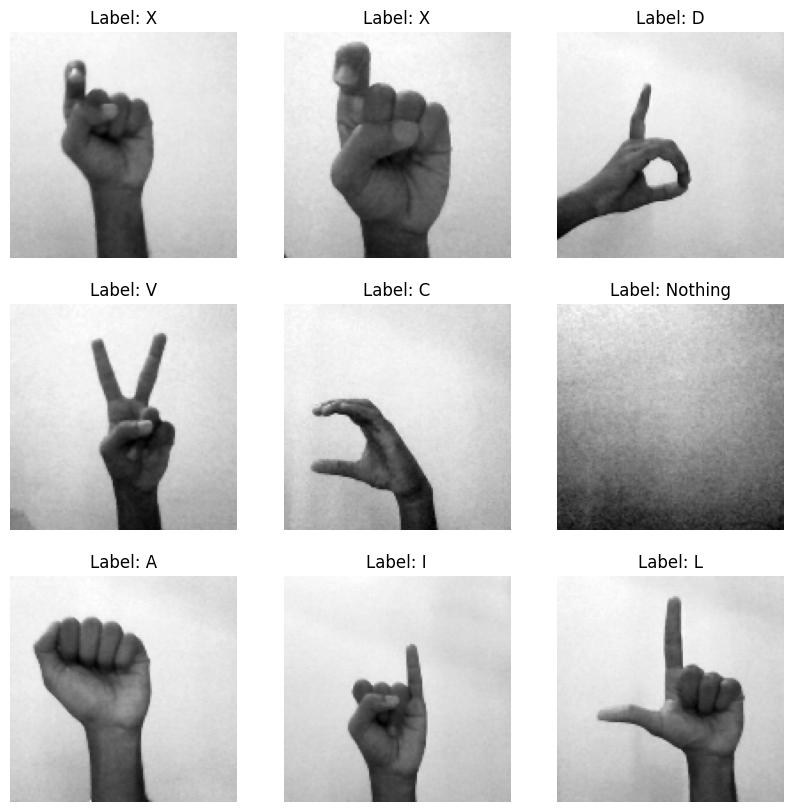

In [ ]:
for images, labels in train_data.take(1):

    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"), cmap='gray')
        label_index = np.argmax(labels[i])
        plt.title(f"Label: {train_data.class_names[label_index]}")
        plt.axis("off")
    plt.show()

Pozrieme sa na to, akú majú obrázky veľkosť

In [ ]:
prvy_priecinok = os.path.join(TRAIN_DIR, CLASSES[0])
prvy_obrazok_nazov = os.listdir(prvy_priecinok)[0]

cesta_k_obrazku = os.path.join(prvy_priecinok, prvy_obrazok_nazov)
img = cv2.imread(cesta_k_obrazku)
print(f"Tvar obrázku (shape): {img.shape}")

vyska = img.shape[0]
sirka = img.shape[1]
kanaly = img.shape[2]
print(f"Rozmery obrázku sú: {sirka} x {vyska} pixelov.")
print(f"Počet farebných kanálov: {kanaly}")

Testujem rozmery obrázku na súbore: /kaggle/input/american-sign-language/ASL_Dataset/Train/A/A1946.jpg
Tvar obrázku (shape): (400, 400, 3)
Rozmery obrázku sú: 400 x 400 pixelov.
Počet farebných kanálov: 3


Vidime ze obrazky su farebné (pocet kanalov 3 = RGB ) - neskôr bude vhodné ich prerobiť do greyscale pre menšie vyťaženie modelu.

## Preprocessing dát

V tejto sekcii aplikujeme **normalizáciu** a **data augmentation** na naše dáta.


### 1. Normalizácia dát

Normalizujeme obrázky z rozsahu [0, 255] na [0, 1] a podľa vypočítaného meanu a std, pre lepšiu konvergenciu tréningu.


### 2. Data Augmentation

Data augmentation pomáha zlepšiť generalizáciu modelu tým, že vytvára variácie trénovacích dát. Použijeme:
- Náhodné rotácie
- Náhodné posuny (translation)
- Náhodné preklopenie (horizontal flip)
- Náhodný zoom
- Náhodné zmeny jasu a kontrastu


In [ ]:
'''
def get_stats_from_raw(dataset, num_batches=10000):    
    sum_img = 0.0
    sum_sq_img = 0.0
    count = 0.0
    
    for images, _ in dataset.take(num_batches):
        images = tf.cast(images, tf.float32) / 255.0

        sum_img += tf.reduce_sum(images)
        sum_sq_img += tf.reduce_sum(tf.square(images))
        count += tf.cast(tf.size(images), tf.float32)
    mean = sum_img / count
    std = tf.sqrt((sum_sq_img / count) - tf.square(mean))
    
    return mean.numpy(), std.numpy()


CALCULATED_MEAN, CALCULATED_STD = get_stats_from_raw(train_data)
print(f"MEAN: {CALCULATED_MEAN:.4f}")
print(f"STD:  {CALCULATED_STD:.4f}")
'''

MEAN: 0.5355
STD:  0.1460


In [ ]:
from tensorflow.keras import layers
STD=0.1458
MEAN=0.5355



data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(factor=0.03, fill_mode='constant'),
    layers.RandomTranslation(height_factor=0.005, width_factor=0.005, fill_mode='constant'),
    layers.RandomZoom(height_factor=0.005, width_factor=0.005, fill_mode='constant'),
    layers.RandomBrightness(factor=0.002),
    layers.RandomContrast(factor=0.002),
], name='data_augmentation')

def preprocess_train(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = data_augmentation(image, training=True)
    safe_std = 1.0 if STD == 0 else STD
    image = (image - MEAN) / safe_std
    return image, label

def preprocess_val(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    safe_std = 1.0 if STD == 0 else STD
    image = (image - MEAN) / safe_std
    return image, label


#Trénovacie dáta
train_ds_final = train_data.map(preprocess_train, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_final = train_ds_final.shuffle(buffer_size=1000).prefetch(tf.data.AUTOTUNE)

# Validačné dáta
test_ds_final = test_data.map(preprocess_val, num_parallel_calls=tf.data.AUTOTUNE)
test_ds_final = test_ds_final.prefetch(tf.data.AUTOTUNE)

Hotovo! Pipeline nastavená: [0-1] -> Augment -> Mean/Std


### 3. Data standardization

### 3. Vizualizácia normalizovaných dát

Pozrime sa, ako vyzerajú augmentované obrázky:


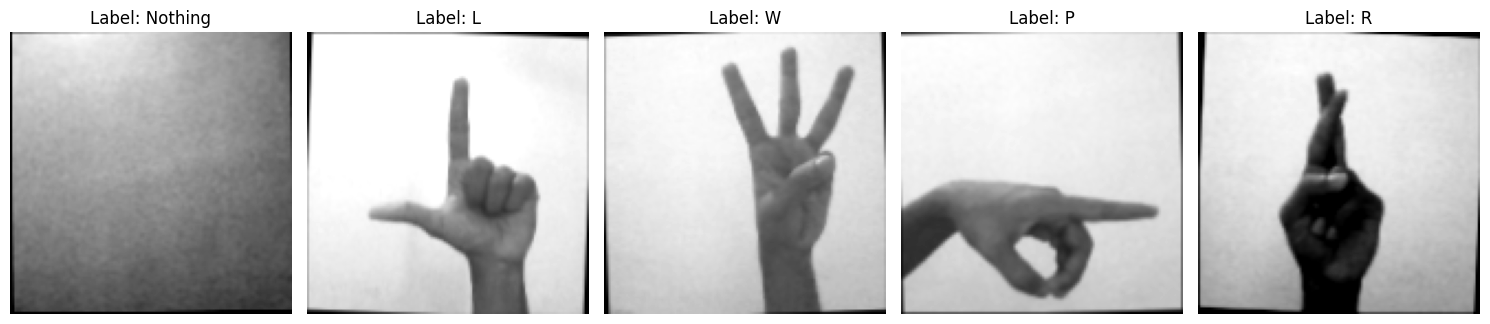

In [ ]:
import matplotlib.pyplot as plt

def denormalize_for_view(image):
    # Vzorec: x_povodna = (x_norm * std) + mean
    safe_std = 1.0 if STD == 0 else STD
    image = (image * safe_std) + MEAN
    return tf.clip_by_value(image, 0.0, 1.0)
images, labels = next(iter(train_ds_final.take(1)))


plt.figure(figsize=(15, 5))
for i in range(5):
    ax = plt.subplot(1, 5, i + 1)
    img_to_show = denormalize_for_view(images[i])
    plt.imshow(img_to_show.numpy(), cmap='gray')
    if len(labels[i].shape) > 0 and labels[i].shape[0] > 1:
        label_val = np.argmax(labels[i])
    else:
        label_val = int(labels[i])
        
    try:
        title = train_data.class_names[label_val]
    except:
        title = str(label_val)
    plt.title(f"Label: {title}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
wandb_key = UserSecretsClient().get_secret("wandb_api")
wandb.login(key=wandb_key)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: xduchona (xkmetk-slovak-technical-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

#### Vlastna modularna cnn, s ktorou budeme experimentovat

In [12]:
# Jednoduchá modulárna CNN architektúra pre ASL klasifikáciu
import tensorflow as tf
from typing import List, Optional, Tuple
from tensorflow.keras import layers, models

class SimpleCNN:
    
    def __init__(
        self,
        input_shape: Tuple[int, int, int] = (128,128, 1),
        num_classes: int = 28,
        num_conv_layers: int = 3,
        filters_per_layer: Optional[List[int]] = None,
        dense_units: Optional[List[int]] = None,
        dropout_rate: float = 0.5,
        use_batch_norm: bool = True,
        use_pooling: bool = True
    ):
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.num_conv_layers = num_conv_layers
        self.dropout_rate = dropout_rate
        self.use_batch_norm = use_batch_norm
        self.use_pooling = use_pooling
        
        # Default filtre
        if filters_per_layer is None:
            self.filters = [32 * (2 ** i) for i in range(num_conv_layers)]
        elif isinstance(filters_per_layer, int):
            self.filters = [filters_per_layer] * num_conv_layers
        else:
            if len(filters_per_layer) != num_conv_layers:
                raise ValueError(f"Počet filtrov ({len(filters_per_layer)}) sa musí rovnať počtu vrstiev ({num_conv_layers})")
            self.filters = filters_per_layer
        
        # Default dense units
        if dense_units is None:
            self.dense_units = [256, 128]
        else:
            self.dense_units = dense_units
    
    def build(self):
        """Vytvorí a vráti model."""
        inputs = layers.Input(shape=self.input_shape, name='input')
        x = inputs
        
        # Konvolučné vrstvy
        for i in range(self.num_conv_layers):
            x = layers.Conv2D(
                filters=self.filters[i],
                kernel_size=3,
                padding='same',
                activation='relu',
                name=f'conv_{i+1}'
            )(x)
            
            if self.use_batch_norm:
                x = layers.BatchNormalization(name=f'bn_{i+1}')(x)
            
            if self.use_pooling:
                x = layers.MaxPooling2D(pool_size=2, name=f'pool_{i+1}')(x)
        
        # Global Average Pooling
        x = layers.GlobalAveragePooling2D(name='global_pool')(x)
        
        # Dense vrstvy
        for i, units in enumerate(self.dense_units):
            x = layers.Dense(units, activation='relu', name=f'dense_{i+1}')(x)
            x = layers.Dropout(self.dropout_rate, name=f'dropout_{i+1}')(x)
        
        # Výstupná vrstva
        outputs = layers.Dense(
            self.num_classes,
            activation='softmax',
            name='output'
        )(x)
        
        model = models.Model(inputs=inputs, outputs=outputs, name='SimpleCNN')
        return model
    
    def compile(
        self,
        optimizer: str = 'adam',
        learning_rate: float = 0.001,
        loss: str = 'categorical_crossentropy',
        metrics: Optional[List[str]] = None
    ):
        """Vytvorí, skompiluje a vráti model."""
        model = self.build()
        
        if optimizer.lower() == 'adam':
            opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
        elif optimizer.lower() == 'sgd':
            opt = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
        else:
            opt = tf.keras.optimizers.get(optimizer)
            if hasattr(opt, 'learning_rate'):
                opt.learning_rate = learning_rate
        
        if metrics is None:
            metrics = ['accuracy']
        
        model.compile(optimizer=opt, loss=loss, metrics=metrics)
        return model


### Tu experimentujeme CNN

In [ ]:

NUM_CLASSES = 28

cnn_model = SimpleCNN(
    input_shape=(*IMG_SIZE, 1),
    num_classes=NUM_CLASSES,
    num_conv_layers=3,  # Môžete zmeniť počet vrstiev
    filters_per_layer=[32, 64, 128],  # Môžete zmeniť počet filtrov
    dense_units=[128],  # Môžete zmeniť počet dense vrstiev
    dropout_rate=0.5,
    use_batch_norm=True,
    use_pooling=True
)

cnn_model = cnn_model.compile(
    optimizer='adam',
    learning_rate=0.001,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks_cnn = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_cnn_model.keras',
        save_best_only=True,
        monitor='val_loss',
        verbose=1
    )
]

print("\nZačínam tréning CNN modelu...")
history_cnn = cnn_model.fit(
    train_ds_final,
    epochs=10,
    validation_data=test_ds_final,
    callbacks=callbacks_cnn,
    verbose=1
)

test_loss, test_accuracy = cnn_model.evaluate(test_ds_final, verbose=1)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Model: "SimpleCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_3 (MaxPooling2D)           │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_pool                     │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 28)             │         3,612 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,692 (444.11 KB)

 Trainable params: 113,244 (442.36 KB)

 Non-trainable params: 448 (1.75 KB)


Začínam tréning CNN modelu...
Epoch 1/10


I0000 00:00:1764451200.493481     113 service.cc:148] XLA service 0x7e4b4c049c10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764451200.494219     113 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1764451201.004540     113 cuda_dnn.cc:529] Loaded cuDNN version 90300


  11/5178 ━━━━━━━━━━━━━━━━━━━━ 1:25 17ms/step - accuracy: 0.0164 - loss: 3.9436     

I0000 00:00:1764451204.462176     113 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5178/5178 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.3391 - loss: 2.2271
Epoch 1: val_loss improved from inf to 0.03646, saving model to best_cnn_model.keras
5178/5178 ━━━━━━━━━━━━━━━━━━━━ 328s 57ms/step - accuracy: 0.3391 - loss: 2.2269 - val_accuracy: 0.9732 - val_loss: 0.0365
Epoch 2/10
5175/5178 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7204 - loss: 0.9669
Epoch 2: val_loss improved from 0.03646 to 0.00016, saving model to best_cnn_model.keras
5178/5178 ━━━━━━━━━━━━━━━━━━━━ 158s 25ms/step - accuracy: 0.7204 - loss: 0.9669 - val_accuracy: 1.0000 - val_loss: 1.6024e-04
Epoch 3/10
5176/5178 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7319 - loss: 0.9242
Epoch 3: val_loss improved from 0.00016 to 0.00010, saving model to best_cnn_model.keras
5178/5178 ━━━━━━━━━━━━━━━━━━━━ 158s 25ms/step - accuracy: 0.7319 - loss: 0.9242 - val_accuracy: 1.0000 - val_loss: 9.5179e-05
Epoch 4/10
5177/5178 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7349 - loss: 0.9181
Epoch 4: val_loss 

# ResNet-50

### Prvé sme sa rozhodli urobiť Res-Net50. Prečo?? Prečo nie, pýtaš sa príliš veľa otázok...

(páči sa mi že má skip connections, je pomerne rýchly a fajn pre stredne veľké množstvo dát, ako máme my)

In [14]:
# Preprocessing už bol vykonaný vyššie v sekcii "Preprocessing dát"
# Používame premenné: train_ds_augmented (pre tréning) a test_ds (pre testovanie)
# Tieto premenné obsahujú normalizované dáta s augmentáciou (pre tréning) alebo bez (pre testovanie)

In [15]:
'''
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

NUM_CLASSES = 28

# 1. Stiahnutie predtrénovaného ResNet50 (bez hornej klasifikačnej vrstvy)
base_model = ResNet50(
    weights='imagenet',  # Použijeme váhy natrénované na ImageNet
    include_top=False,   # Odstránime poslednú vrstvu
    input_shape=(224, 224, 3)
)

# 2. Zmrazenie váh base modelu
base_model.trainable = False

# 3. Vytvorenie nového modelu
model = models.Sequential([
    # Augmentácia dát (náhodné preklopenie/otočenie pre lepšiu robustnosť)
    # layers.RandomFlip("horizontal"),
    # layers.RandomRotation(0.1),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(256, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# 4. Kompilácia modelu
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
'''

'\nfrom tensorflow.keras.applications import ResNet50\nfrom tensorflow.keras import layers, models\n\nNUM_CLASSES = 28\n\n# 1. Stiahnutie predtrénovaného ResNet50 (bez hornej klasifikačnej vrstvy)\nbase_model = ResNet50(\n    weights=\'imagenet\',  # Použijeme váhy natrénované na ImageNet\n    include_top=False,   # Odstránime poslednú vrstvu\n    input_shape=(224, 224, 3)\n)\n\n# 2. Zmrazenie váh base modelu\nbase_model.trainable = False\n\n# 3. Vytvorenie nového modelu\nmodel = models.Sequential([\n    # Augmentácia dát (náhodné preklopenie/otočenie pre lepšiu robustnosť)\n    # layers.RandomFlip("horizontal"),\n    # layers.RandomRotation(0.1),\n    base_model,\n    layers.GlobalAveragePooling2D(),\n    layers.Dropout(0.2),\n    layers.Dense(256, activation=\'relu\'),\n    layers.Dense(NUM_CLASSES, activation=\'softmax\')\n])\n\n# 4. Kompilácia modelu\nmodel.compile(\n    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),\n    loss=\'categorical_crossentropy\',\n    metrics=[\

In [16]:
'''
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import wandb


from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint
wandb.init(project="ASL_ResNet", config={"model": "ResNet50", "epochs": 10})

callbacks = [
    EarlyStopping(
        monitor='val_loss', 
        patience=3, 
        restore_best_weights=True,
        verbose=1
    ),
    
    ModelCheckpoint(
        "best_asl_resnet.keras", 
        save_best_only=True, 
        monitor='val_loss',
        verbose=1
    ),
    WandbMetricsLogger()
]


history = model.fit(
    train_ds_augmented,  # Používame augmentované trénovacie dáta z preprocessing sekcie
    epochs=10,
    validation_data=test_ds,  # Testovacie dáta (normalizované, bez augmentácie)
    callbacks=callbacks
)
wandb.finish()
'''

'\nimport tensorflow as tf\nfrom tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint\nimport wandb\n\n\nfrom wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint\nwandb.init(project="ASL_ResNet", config={"model": "ResNet50", "epochs": 10})\n\ncallbacks = [\n    EarlyStopping(\n        monitor=\'val_loss\', \n        patience=3, \n        restore_best_weights=True,\n        verbose=1\n    ),\n    \n    ModelCheckpoint(\n        "best_asl_resnet.keras", \n        save_best_only=True, \n        monitor=\'val_loss\',\n        verbose=1\n    ),\n    WandbMetricsLogger()\n]\n\n\nhistory = model.fit(\n    train_ds_augmented,  # Používame augmentované trénovacie dáta z preprocessing sekcie\n    epochs=10,\n    validation_data=test_ds,  # Testovacie dáta (normalizované, bez augmentácie)\n    callbacks=callbacks\n)\nwandb.finish()\n'

Do budúcnosti premýľame že výskúšame aj tieto modeli

EfficientNet, MobileNetV3